In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import drive
import statsmodels.api as sm
import numpy as np

In [ ]:
file_path = "/content/drive/MyDrive/Analisis matemático/FINALMODELOajustelocal.csv"
df_modelo = pd.read_csv(file_path, encoding='latin1')

In [ ]:
# 1. Crear nuevos dummies

# China moderna (año >= 2000)
df_modelo["DUMMY_CHINA_MODERNA"] = df_modelo.apply(lambda row: 1 if row["COUNTRY"] == "China" and row["YEAR"] >= 2008 else 0, axis=1)
df_modelo["DUMMY_KOREA_MODERNA"] = df_modelo.apply(lambda row: 1 if row["COUNTRY"] == "South Korea" and row["YEAR"] >= 1988 else 0, axis=1)

# Francia (en general)
df_modelo["DUMMY_FRANCE"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "France" else 0)
df_modelo["DUMMY_ITALY"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Italy" else 0)
df_modelo["DUMMY_HUNGARY"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Hungary" else 0)
df_modelo["DUMMY_JAPAN"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Japan" else 0)
df_modelo["DUMMY_BULGARIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Bulgaria" else 0)
df_modelo["DUMMY_CUBA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Cuba" else 0)
df_modelo["DUMMY_NETHERLANDS"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Netherlands" else 0)
df_modelo["DUMMY_NETHERLANDS"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Netherlands" else 0)
df_modelo["DUMMY_ROMANIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Romania" else 0)
df_modelo["DUMMY_SPAIN"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Spain" else 0)
# 2. Redefinir X con las nuevas variables
X = df_modelo[[
    "PIB_REAL",
    "POBLACION_TOTAL_CENTRADO",
    "POBLACION_20_24_CENTRADO",
    "TASA_MORTALIDAD_INFANTIL_CENTRADO",
    "LOCAL",
    "VECINO",
   #"DUMMY_CHINA_MODERNA",
    "DUMMY_RUSSIA",
    "DUMMY_USA",
    "DUMMY_GERMANY",
   # "BOICOT_1980",
   # "BOICOT_1984",
    "DUMMY_AUSTRALIA",
    "DUMMY_UK",
    "DUMMY_FRANCE",
    "DUMMY_ITALY",
    "DUMMY_HUNGARY",
    "DUMMY_JAPAN",
    "DUMMY_BULGARIA",
    "DUMMY_CUBA",
    "DUMMY_KOREA_MODERNA",
    "DUMMY_NETHERLANDS",
    "DUMMY_ROMANIA",
    "DUMMY_SPAIN"

]]

# 3. Agregar constante
X = sm.add_constant(X)

# 4. Definir y
y= df_modelo["PROP_MEDALLAS"]

# 5. Ajustar el modelo
modelo= sm.OLS(y, X).fit()

# 6. Mostrar el resumen del modelo
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:          PROP_MEDALLAS   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     165.9
Date:                Wed, 30 Apr 2025   Prob (F-statistic):          1.32e-313
Time:                        15:42:31   Log-Likelihood:                 2946.8
No. Observations:                1059   AIC:                            -5850.
Df Residuals:                    1037   BIC:                            -5740.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

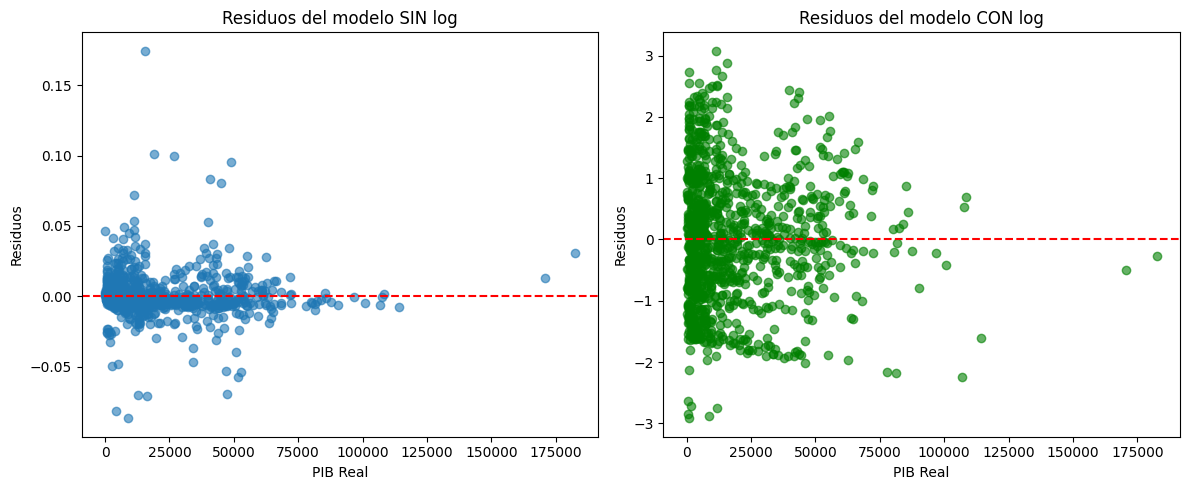

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
df_modelo["DUMMY_CHINA_MODERNA"] = df_modelo.apply(lambda row: 1 if row["COUNTRY"] == "China" and row["YEAR"] >= 2008 else 0, axis=1)
df_modelo["DUMMY_KOREA_MODERNA"] = df_modelo.apply(lambda row: 1 if row["COUNTRY"] == "South Korea" and row["YEAR"] >= 1988 else 0, axis=1)

# Francia (en general)
df_modelo["DUMMY_FRANCE"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "France" else 0)
df_modelo["DUMMY_ITALY"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Italy" else 0)
df_modelo["DUMMY_HUNGARY"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Hungary" else 0)
df_modelo["DUMMY_JAPAN"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Japan" else 0)
df_modelo["DUMMY_BULGARIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Bulgaria" else 0)
df_modelo["DUMMY_CUBA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Cuba" else 0)
df_modelo["DUMMY_NETHERLANDS"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Netherlands" else 0)
df_modelo["DUMMY_NETHERLANDS"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Netherlands" else 0)
df_modelo["DUMMY_ROMANIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Romania" else 0)
df_modelo["DUMMY_SPAIN"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Spain" else 0)
# Definir variables
X_vars = [
    "PIB_REAL",
    "POBLACION_TOTAL_CENTRADO",
    "POBLACION_20_24_CENTRADO",
    "TASA_MORTALIDAD_INFANTIL_CENTRADO",
    "LOCAL", "VECINO",
    "DUMMY_RUSSIA", "DUMMY_USA", "DUMMY_GERMANY",
    "DUMMY_AUSTRALIA", "DUMMY_UK", "DUMMY_FRANCE", "DUMMY_ITALY",
    "DUMMY_HUNGARY", "DUMMY_JAPAN", "DUMMY_BULGARIA", "DUMMY_CUBA",
    "DUMMY_KOREA_MODERNA", "DUMMY_NETHERLANDS", "DUMMY_ROMANIA", "DUMMY_SPAIN"
]

# Eliminar filas con NaN
df_modelo = df_modelo.dropna(subset=X_vars + ["PROP_MEDALLAS", "LOG_PROP_MEDALLAS"])

# Preparar variables independientes
X = sm.add_constant(df_modelo[X_vars])
y1 = df_modelo["PROP_MEDALLAS"]
y2 = df_modelo["LOG_PROP_MEDALLAS"]

# Ajustar ambos modelos
modelo_sin_log = sm.OLS(y1, X).fit()
modelo_con_log = sm.OLS(y2, X).fit()

# Graficar residuos vs PIB
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_modelo["PIB_REAL"], modelo_sin_log.resid, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos del modelo SIN log")
plt.xlabel("PIB Real")
plt.ylabel("Residuos")

plt.subplot(1, 2, 2)
plt.scatter(df_modelo["PIB_REAL"], modelo_con_log.resid, alpha=0.6, color="green")
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos del modelo CON log")
plt.xlabel("PIB Real")
plt.ylabel("Residuos")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# 1. Predecir log(ŵ_it) con el modelo
log_predicciones = modelo.predict(X)

# 2. Destransformar: volver a escala real (ŵ_it)
predicciones = np.exp(log_predicciones)

# 3. Agregar las predicciones al dataframe de modelado
df_modelo["PROP_MEDALLAS_PREDICHA"] = predicciones

# 4. Opcional: calcular error absoluto entre proporción real y predicha
df_modelo["ERROR_ABSOLUTO"] = np.abs(df_modelo["PROP_MEDALLAS"] - df_modelo["PROP_MEDALLAS_PREDICHA"])

# 5. Mostrar ejemplo de tabla de resultados
resultados = df_modelo[[
    "COUNTRY",
    "YEAR",
    "MEDALLAS_TOTALES_POR_PAIS_POR_AÑO",
    "PROP_MEDALLAS",
    "PROP_MEDALLAS_PREDICHA",
    "ERROR_ABSOLUTO"
]].sort_values(by="ERROR_ABSOLUTO", ascending=False)

# Mostrar los 10 países con mayor error
resultados.head(10)


,COUNTRY,YEAR,MEDALLAS_TOTALES_POR_PAIS_POR_AÑO,PROP_MEDALLAS,PROP_MEDALLAS_PREDICHA,ERROR_ABSOLUTO
805,Russia,2016,115,0.057072,1.154695,1.097623
800,Russia,1996,115,0.062466,1.155010,1.092544
804,Russia,2012,140,0.072389,1.153822,1.081433
803,Russia,2008,142,0.069574,1.149653,1.080079
365,Germany,2020,81,0.035464,1.110437,1.074973
362,Germany,2008,99,0.048506,1.111500,1.062994
801,Russia,2000,187,0.093547,1.154187,1.060641
366,Germany,2024,108,0.047682,1.107133,1.059451
802,Russia,2004,189,0.094880,1.153633,1.058753
363,Germany,2012,94,0.048604,1.107162,1.058558


In [ ]:
# 1. Primero, recuperar el total de medallas entregadas cada año
total_medallas_por_ano = df_modelo.groupby("YEAR")["MEDALLAS_TOTALES_POR_PAIS_POR_AÑO"].transform("sum")

# 2. Calcular las medallas reales y predichas en números absolutos
df_modelo["MEDALLAS_REALES"] = df_modelo["PROP_MEDALLAS"] * total_medallas_por_ano
df_modelo["MEDALLAS_PREDICHAS"] = df_modelo["PROP_MEDALLAS_PREDICHA"] * total_medallas_por_ano

# 3. Calcular error absoluto en número de medallas
df_modelo["ERROR_ABSOLUTO_MEDALLAS"] = np.abs(df_modelo["MEDALLAS_REALES"] - df_modelo["MEDALLAS_PREDICHAS"])

# 4. Armar la tabla ordenada
tabla_resultados = df_modelo[[
    "COUNTRY",
    "YEAR",
    "MEDALLAS_REALES",
    "MEDALLAS_PREDICHAS",
    "ERROR_ABSOLUTO_MEDALLAS"
]].sort_values(by="ERROR_ABSOLUTO_MEDALLAS", ascending=False)

# 5. Mostrar los 10 países con mayor error absoluto
tabla_resultados.head(100)


,COUNTRY,YEAR,MEDALLAS_REALES,MEDALLAS_PREDICHAS,ERROR_ABSOLUTO_MEDALLAS
365,Germany,2020,81.000000,2536.237338,2455.237338
366,Germany,2024,108.000000,2507.656863,2399.656863
1028,United States,2020,298.000001,2642.378690,2344.378689
423,India,2020,24.000000,2366.889426,2342.889426
790,Romania,2020,8.999999,2338.978676,2329.978677
...,...,...,...,...,...
760,Portugal,2024,5.000001,2277.838719,2272.838718
524,Jordan,2024,1.000000,2273.694638,2272.694638
200,Colombia,2024,3.999999,2276.657019,2272.657020
85,Bahrain,2024,3.999999,2276.596232,2272.596232


In [ ]:
df=tabla_resultados

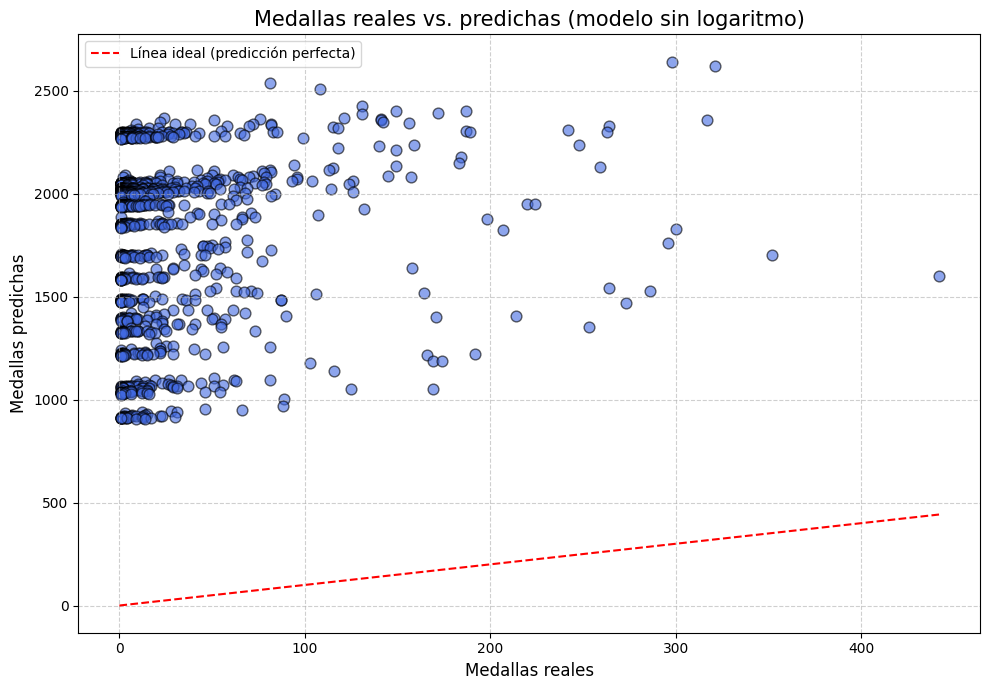

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar archivo de resultados
#df = pd.read_excel("RESULTADOS5.xlsx")  # Asegúrate de tener este archivo en tu carpeta de trabajo

# 2. Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# 3. Seleccionar las columnas necesarias y eliminar valores nulos
df_grafico = df[["COUNTRY", "YEAR", "MEDALLAS_REALES", "MEDALLAS_PREDICHAS"]].dropna()

# 4. Crear gráfico
plt.figure(figsize=(10, 7))
plt.scatter(
    df_grafico["MEDALLAS_REALES"],
    df_grafico["MEDALLAS_PREDICHAS"],
    alpha=0.6,
    color='royalblue',
    edgecolors='black',
    s=60,
    marker='o'
)
plt.plot(
    [0, df_grafico["MEDALLAS_REALES"].max()],
    [0, df_grafico["MEDALLAS_REALES"].max()],
    'r--',
    label='Línea ideal (predicción perfecta)'
)

# 5. Etiquetas y formato
plt.title("Medallas reales vs. predichas (modelo sin logaritmo)", fontsize=15)
plt.xlabel("Medallas reales", fontsize=12)
plt.ylabel("Medallas predichas", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 6. Mostrar
plt.show()


In [ ]:
import pandas as pd

# 1. Cargar archivo de resultados
df.columns = df.columns.str.strip()

# 2. Agrupar por país y sumar medallas reales y predichas
tabla_resumen = df.groupby("COUNTRY")[["MEDALLAS_REALES", "MEDALLAS_PREDICHAS"]].sum().reset_index()

# 3. Calcular el error absoluto total por país
tabla_resumen["ERROR_ABSOLUTO_TOTAL"] = abs(tabla_resumen["MEDALLAS_REALES"] - tabla_resumen["MEDALLAS_PREDICHAS"])

# 4. Renombrar columnas para claridad
tabla_resumen.columns = ["COUNTRY", "MEDALLAS_REALES_TOTALES", "MEDALLAS_PREDICHAS_TOTALES", "ERROR_ABSOLUTO_TOTAL"]

# 5. Ordenar por error total (opcional: puedes cambiar a orden por medallas reales si lo prefieres)
tabla_resumen = tabla_resumen.sort_values("ERROR_ABSOLUTO_TOTAL", ascending=False)

# 6. Mostrar las primeras filas
print(tabla_resumen.head(15))

# (Opcional) Guardar a Excel
tabla_resumen.to_excel("resumen_medallas_totales_con_errores.xlsx", index=False)


            COUNTRY  MEDALLAS_REALES_TOTALES  MEDALLAS_PREDICHAS_TOTALES  \
46          Germany              2682.000002                31136.121669   
13          Belgium               113.000001                28242.790894   
75           Mexico               112.000002                28231.633758   
113     Switzerland               156.000001                28274.009091   
98          Romania               641.000001                28727.000300   
60            Italy               982.000000                29043.347498   
6         Australia              1410.000002                29385.650401   
127  United Kingdom              1143.999998                29118.207528   
43           France              1047.000001                29015.973553   
82      Netherlands               789.000000                28743.355721   
32          Denmark               329.999996                28267.993977   
112          Sweden               350.000001                28274.888311   
16          